# Predicting Protein Prediction

Consider as starting point for this exercise a UCI Protein Structure. The dataset comes from the Critical Assessment of protein Structure Prediction experiments (CASP), which is a recurrent (biannual) initiative to predict protein structure from experimental data.

The dataset consists of roughly 45k entries with nine features and one target. 

The features essentially are calculated physicochemical descriptors:
- F1: Total surface area (Approximate exposed surface of the protein)
- F2: Non-polar exposed area (Hydrophobic surface)
- F3: "Fraction of exposed nonpolar area" (Ratio of hydrophobic and total surface)
- F4: Residue surface exposure (How much amino acids are exposed)
- F5: Secondary structure agreement (Measures consistency with expected structures (α-helices, β-sheets))
- F6: Pairwise distance features (Encodes distances between residues)
- F7: Compactness / packing (How tightly folded the protein is)
- F8: Structural energy-related feature (Proxy for physical plausibility)
- F9: Additional geometric descriptor (Captures global structure properties)

The target is the RMSD (Root Mean Squared Deviation) that describes the deviation of the predicted from the true protein structure. 

The aim of the exercise is to build a model to predict how accurate predicted structures would be based on calculated descriptors.

#### Tasks:
1) The data is somewhat abstract. Inspect it to see what can be expected of a potential model.
2) Create feature matrix and target vector.
3) Choose one Regression ML model, build it and optimise (consider scaling if the model class needs it)
4) Take note of the training and test time for your model (approximation is enough)
5) Whatever model you end up using, try to optimise for accuracy and minimal overfitting, use **MSE** for evaluating your model!
6) Respond to the discussion points.

#### Note:
Feel free in your choice in model class, everything covered in the course so far is on the table. You don't need to compare different ones, we will do that with the compiled results of all assignments.

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingGridSearchCV


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


Load and investigate the data

In [2]:
df = pd.read_csv("CASP.csv")
df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


Build feature matrix and target vector. Add scaling if needed for your model.

In [3]:
X = df.drop('RMSD', axis=1)
y = df['RMSD']

> using Radnom forest, no scaling or standardisation needed

Choose a Regression model, build, train and optimise

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Random Forest

In [5]:
model=RandomForestRegressor(n_estimators=300, random_state=42)
name="Random Forest"
model.fit(X_train, y_train)
    
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
    
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
    
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

rf_results={"Name": "Random Forest",
            "Train RMSE" : train_mse, 
            "Test  RMSE" : test_mse,
            "Train R²" : train_r2,
            "Test  R²" : test_r2,
            "y_pred" : y_test_pred
            }


Tuned GridSearchCV Random Forest

In [6]:

# Define parameter grid
param_grid = {
    #'n_estimators': [50, 300],
    'max_depth': [None, 1, 3, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6]
}

# Perform grid search
grid_search = HalvingGridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           factor=3,
                           resource='n_estimators',
                           max_resources=40, 
                           cv=5,
                           scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (string) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 1, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_estimators'
,"max_resources max_resources: int, default='auto'The maximum amount of resource that any candidate is allowed to usefor a given iteration. By default, this is set to ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",40
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='exhaust'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'exhaust'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... note:: Due to implementation details, the folds produced by `cv` must be the same across multiple calls to `cv.split()`. For built-in `scikit-learn` iterators, this can be achieved by deactivating shuffling (`shuffle=False`), or by setting the `cv`'

Evaluate your best model (MSE). Take note of training and test time (approximate).

In [7]:
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 27}


In [17]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

rf_tuned_results={"Name": "Tuned Random Forest",
            "Train MSE" : train_mse, 
            "Test  MSE" : test_mse,
            "Train R² " : train_r2,
            "Test  R² " : test_r2,
            "y_pred   " : y_test_pred}



Comparison

In [9]:
for key, val in rf_results.items():
    if type(val)!=float:
        print(f"{key}: {val}")
    else:
        print(f"{key}: {val:.3f}")

print("-" * 40)
for key, val in rf_tuned_results.items():
    if type(val)!=float:
        print(f"{key}: {val}")
    else:
        print(f"{key}: {val:.3f}")
    

Name: Random Forest
Train RMSE: 1.685
Test  RMSE: 12.411
Train R²: 0.955
Test  R²: 0.670
y_pred: [13.37969667  4.04610667  5.05544    ...  2.70487333  6.16416
 12.32102   ]
----------------------------------------
Name: Tuned Random Forest
Train MSE: 5.529
Test  MSE: 13.508
Train R² : 0.852
Test  R² : 0.641
y_pred   : [13.30220141  3.64644889  4.77780508 ...  2.94474543  7.30874104
 12.94706228]


feature importance

In [10]:
feature_names = ["F1: Total surface area", "F2: Non-polar exposed area", 
                "F3: Fraction of exposed nonpolar area", "F4: Residue surface exposure", 
                "F5: Secondary structure agreement", "F6: Pairwise distance features", 
                "F7: Compactness / packing", "F8: Structural energy-related feature", "F9: Additional geometric descriptor"]

tuned_importances = best_model.feature_importances_
rf_importances = model.feature_importances_


print("RF:")
for name, imp in sorted(zip(feature_names, rf_importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

print("\n")
print("-"* 40)
print("Tuned:")
for name, imp in sorted(zip(feature_names, tuned_importances), key=lambda x: -x[1]):
    print(f"{name}: {imp:.3f}")

RF:
F3: Fraction of exposed nonpolar area: 0.201
F4: Residue surface exposure: 0.181
F8: Structural energy-related feature: 0.131
F6: Pairwise distance features: 0.102
F7: Compactness / packing: 0.101
F5: Secondary structure agreement: 0.088
F9: Additional geometric descriptor: 0.078
F2: Non-polar exposed area: 0.064
F1: Total surface area: 0.053


----------------------------------------
Tuned:
F3: Fraction of exposed nonpolar area: 0.217
F4: Residue surface exposure: 0.191
F8: Structural energy-related feature: 0.132
F6: Pairwise distance features: 0.097
F7: Compactness / packing: 0.096
F5: Secondary structure agreement: 0.086
F9: Additional geometric descriptor: 0.069
F2: Non-polar exposed area: 0.062
F1: Total surface area: 0.049


Graphs

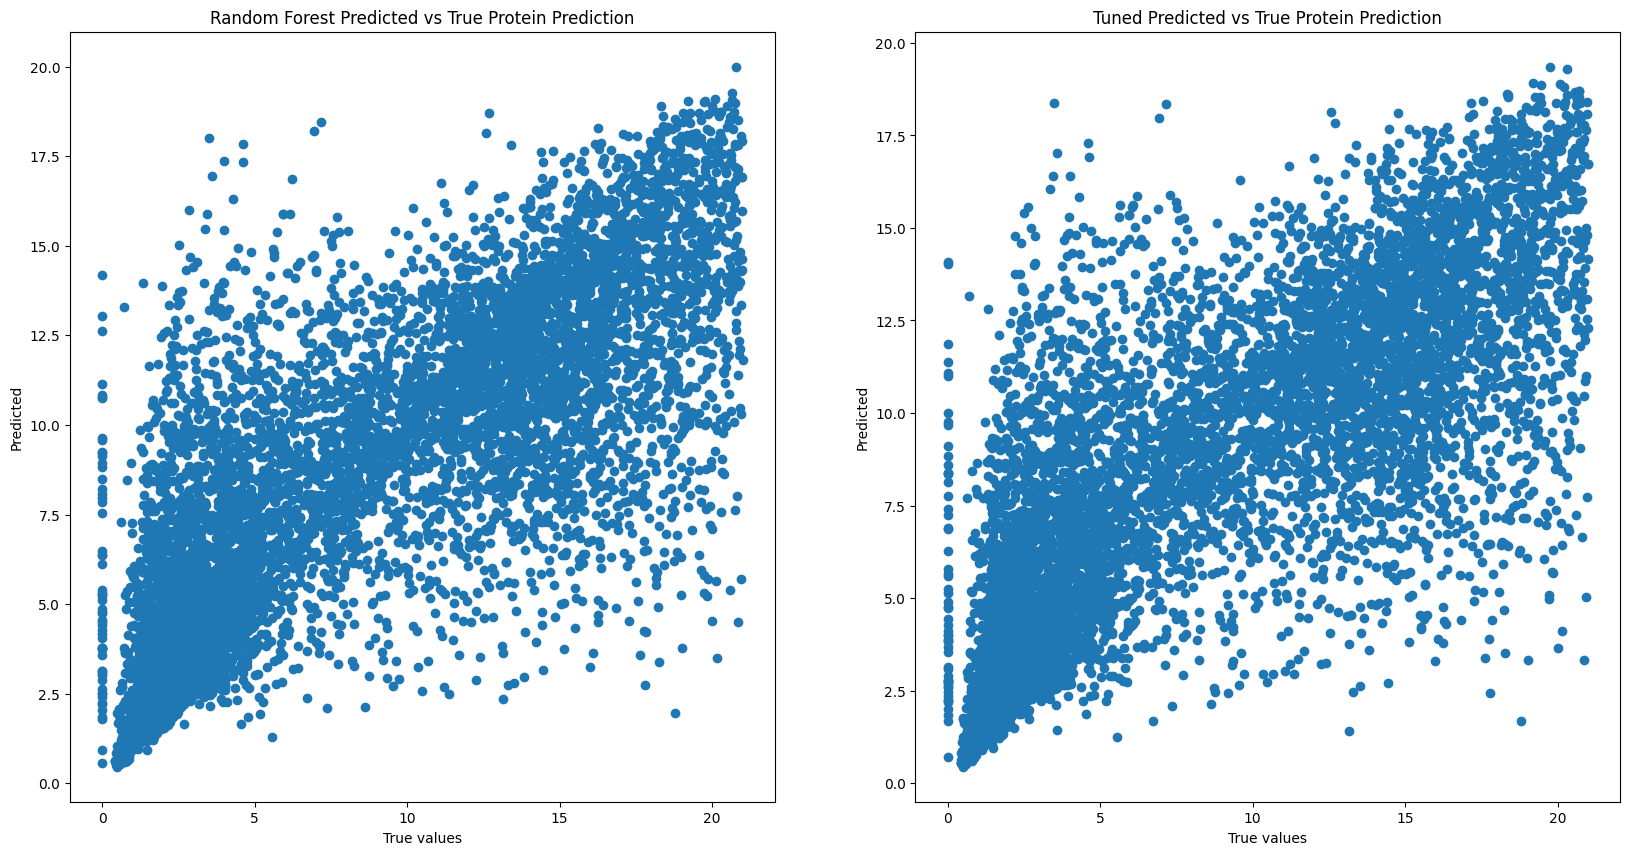

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

sc0=axes[ 0].scatter(y_test, rf_results["y_pred"])
axes[0].set_title("Random Forest Predicted vs True Protein Prediction")
axes[0].set_xlabel("True values")
axes[0].set_ylabel("Predicted")


sc1 = axes[1].scatter(y_test, rf_tuned_results["y_pred   "])
axes[1].set_title("Tuned Predicted vs True Protein Prediction")
axes[ 1].set_xlabel("True values")
axes[1].set_ylabel("Predicted")


plt.show()

#### Discussion points
1) Discuss your choice of model class.
2) How did you optimise your model? How did the best model perform?
3) How much time was needed for training the model and evaluations (approximation is enough)?
4) What limitations or shortcomings did you identify? What would be ideas to remedy or circumvent them?
5) In all its abstraction, what do the predictions of your model tell you?

1) Chose Random Forest, on one hand you recced it to me, on the other as wee saw last week it performed similarly well to the NN, although it was a classification ex so actually kind of not applicable. It was the second best model for me in ex. 1B regression. 
I also tried tuning the hyperparameters iôf it using HalvingGridSearchCV bc the GridSeachCV was taking too long (> 20mins), so I stoped it.

2) I played around with the RF with the parameters from the GridSearch and vice versa but to no effect. RF gave slightly better results when I increase nestimators from 200 to 300 but not by  a lot. GridSeach I gav eit more options to choose from and also tried letting it optimise nsamples instead of nestimators but that gave very bad results (r2 of 1). 

3) Barely any, RF took 54.2 seconds and the HalvingGridSearchCV 1.46min

4) Time nesccecary to run GridSeachCV, I felt like I didn't have that many parameters to alter in RF, maybe a me problem. Time could defo be helped by doing some sort of batch training so the packages are smaller. I also feel like a clustering technique would be optimaal to see the similarities (butina), but idk if that's possible for regression. 

5) the feature importances indiate that the F3: Fraction of exposed nonpolar area (0.217), F4: Residue surface exposure (0.191), F8: Structural energy-related feature (0.132) are important descriptors. It alsoo highlights the difficulty of structure prediction as visible in the graphs. 

> could also do PCA

5) predicts the prodection precision

## Podcast notes


NN param : weight_decay -> rel to opimiser , regularisation parameter, reduce overfitting, so no overpronounce the effect of everything the model learns in every single epoch. 

Epoch: limit to red overfitting, early stopping

AdamW: Opimiser with Weight decay as regularisation 

<blockquote>

@ Discussion:
RF ist immer eine gute Wahl out of the Box - und völlig richtig: Keine Standardisierung notwendig 🙂
Man sieht das auch recht gut am Vergleich zwischen unoptimiert und optimiert - sind sehr ähnlich, nur ist das Overfitting ein bisschen besser mit dem optimierten Modell.
   4) Gut, der Datensatz ist natürlich riesig, da dauert das wiederholte Trainieren und Evaluieren einfach lange. Das wäre definitiv eine Mglichkeit für Random Sampling. Ein weiteres Problem ist Overfitting, bis zu einem gewissen Grad kann man das mit den Hyperparametern in den Griff bekommen ("Pruning"), allerdings ist das ein inherentes Problem von Tree-basierten Modellen. Clustering kann fürs Verständnis helfen und auch fürs Feature-Engineering (auch fürs Sampling, damit man einen guten Queerschnitt über den Datensatz behält - ähnlich wie beim Stratify (was es allerdings nur für Klassifikationen gibt)) - ähnlich wie dimensionality reduction. Allerdings ist in dem Beispiel der Feature Space gar nicht so umfangreich (sind ja nur 9), sondern mehr die Anzahl der Samples.

@Handwriting/MNIST: Danke für das Update - leider ist das sehr vom Input abhängig, habe ich nachher gesehen. Es müssen die Zahlen schön mittig sein, sollen ungefähr eine ähnliche Grösse haben und am besten einen dicken Strich. Das Script war so ausgelegt, dass es automatisch invertiert btw - also war der Gedanke schwarz auf weiss zu schreiben. Muss mich da selber ein bisschen damit spielen und diese Rahmenbedingungen in das Notebook übernehmen. Merci fürs Testen!!